# Credit Scoring — Business Problem

## Problem Statement

Predict `SeriousDlqin2yrs` - whether a borrower will experience serious delinquency
(90+ days past due) within 2 years, based on financial behavior and demographic data.

## Business Value

Accurate default prediction helps financial institutions minimize credit losses,
make fair lending decisions, set appropriate credit limits, and comply with
regulatory requirements for risk management.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE

sns.set_theme(style='whitegrid', palette='muted')

In [4]:
train = pd.read_csv("cs-training.csv")
test  = pd.read_csv("cs-test.csv")

In [6]:
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df = train.copy()

In [8]:
df.shape

(150000, 12)

In [9]:
df = df.drop("Unnamed: 0", axis=1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [11]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [13]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [14]:
df.isnull().mean().round(4)

SeriousDlqin2yrs                        0.0000
RevolvingUtilizationOfUnsecuredLines    0.0000
age                                     0.0000
NumberOfTime30-59DaysPastDueNotWorse    0.0000
DebtRatio                               0.0000
MonthlyIncome                           0.1982
NumberOfOpenCreditLinesAndLoans         0.0000
NumberOfTimes90DaysLate                 0.0000
NumberRealEstateLoansOrLines            0.0000
NumberOfTime60-89DaysPastDueNotWorse    0.0000
NumberOfDependents                      0.0262
dtype: float64

EDA

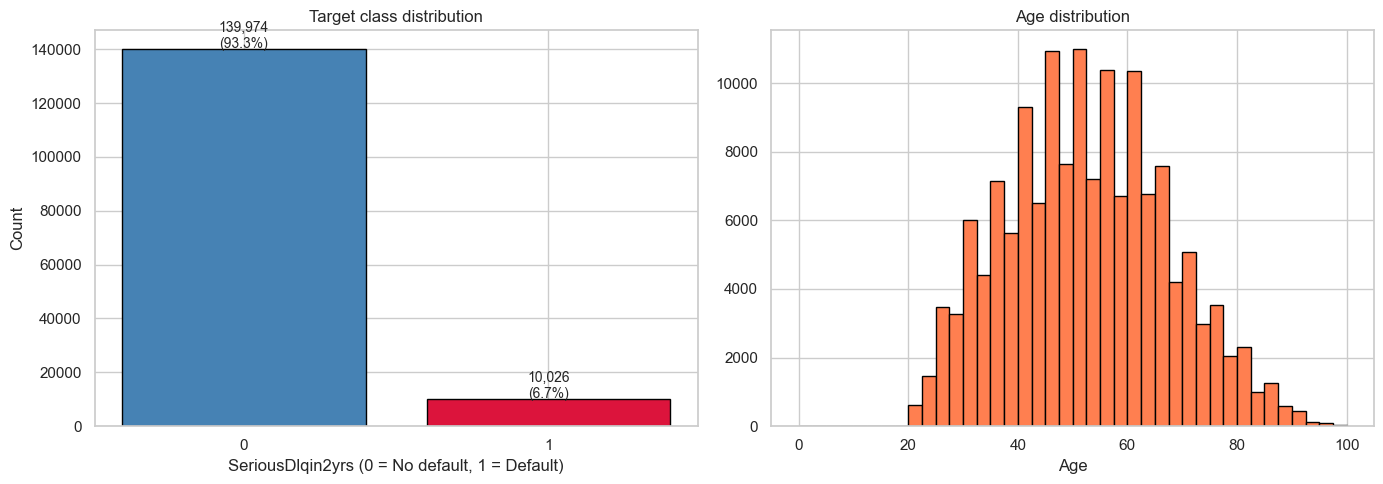

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(counts.index.astype(str), counts.values, color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Target class distribution')
axes[0].set_xlabel('SeriousDlqin2yrs (0 = No default, 1 = Default)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

df['age'].clip(upper=100).hist(bins=40, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Age distribution')
axes[1].set_xlabel('Age')
plt.tight_layout()
plt.show()

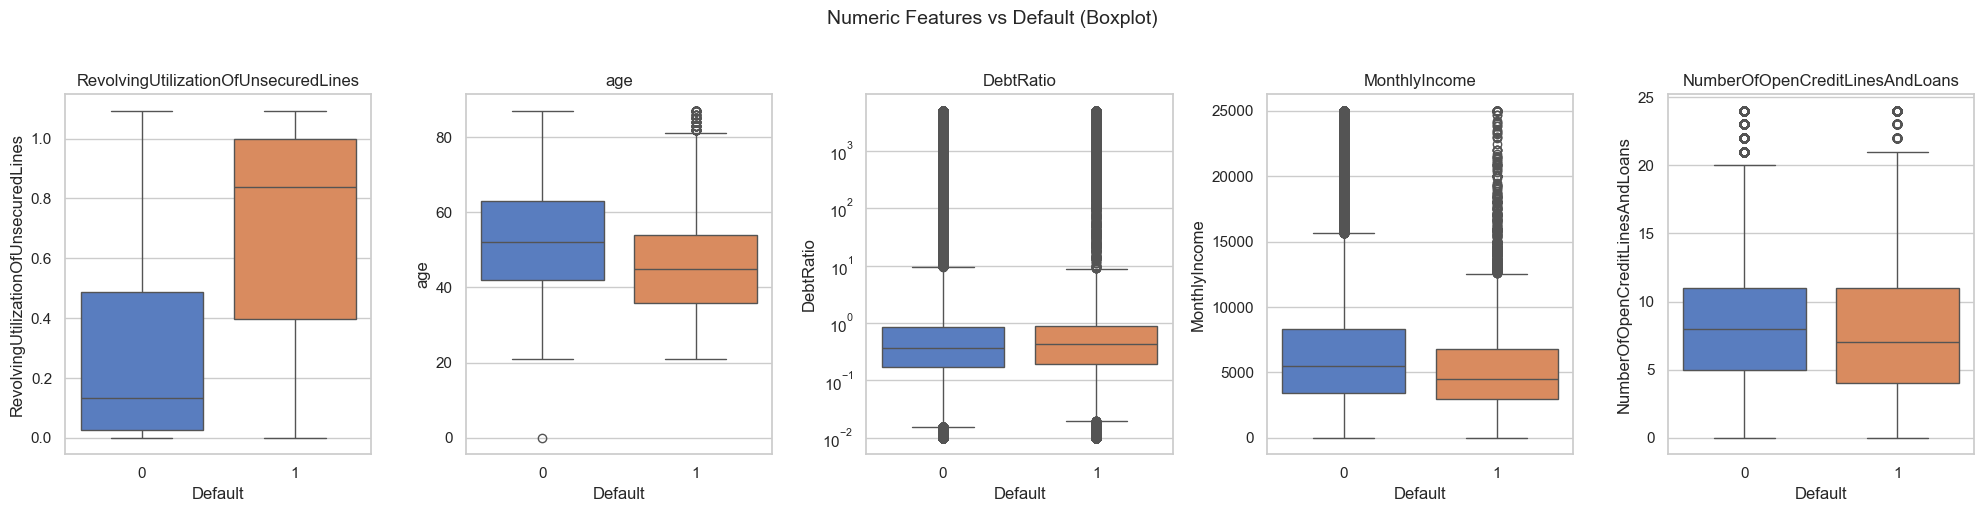

In [16]:
num_features = ['RevolvingUtilizationOfUnsecuredLines', 'age',
                'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

fig, axes = plt.subplots(1, len(num_features), figsize=(20, 5))

for ax, feat in zip(axes, num_features):
    plot_df = df[[feat, 'SeriousDlqin2yrs']].dropna()
    plot_df[feat] = plot_df[feat].clip(upper=plot_df[feat].quantile(0.99))

    if feat == 'DebtRatio':
        plot_df[feat] = plot_df[feat].clip(lower=0.01)
        ax.set_yscale('log')

    sns.boxplot(data=plot_df, x='SeriousDlqin2yrs', y=feat, ax=ax, palette='muted')
    ax.set_title(feat)
    ax.set_xlabel('Default')

plt.suptitle('Numeric Features vs Default (Boxplot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

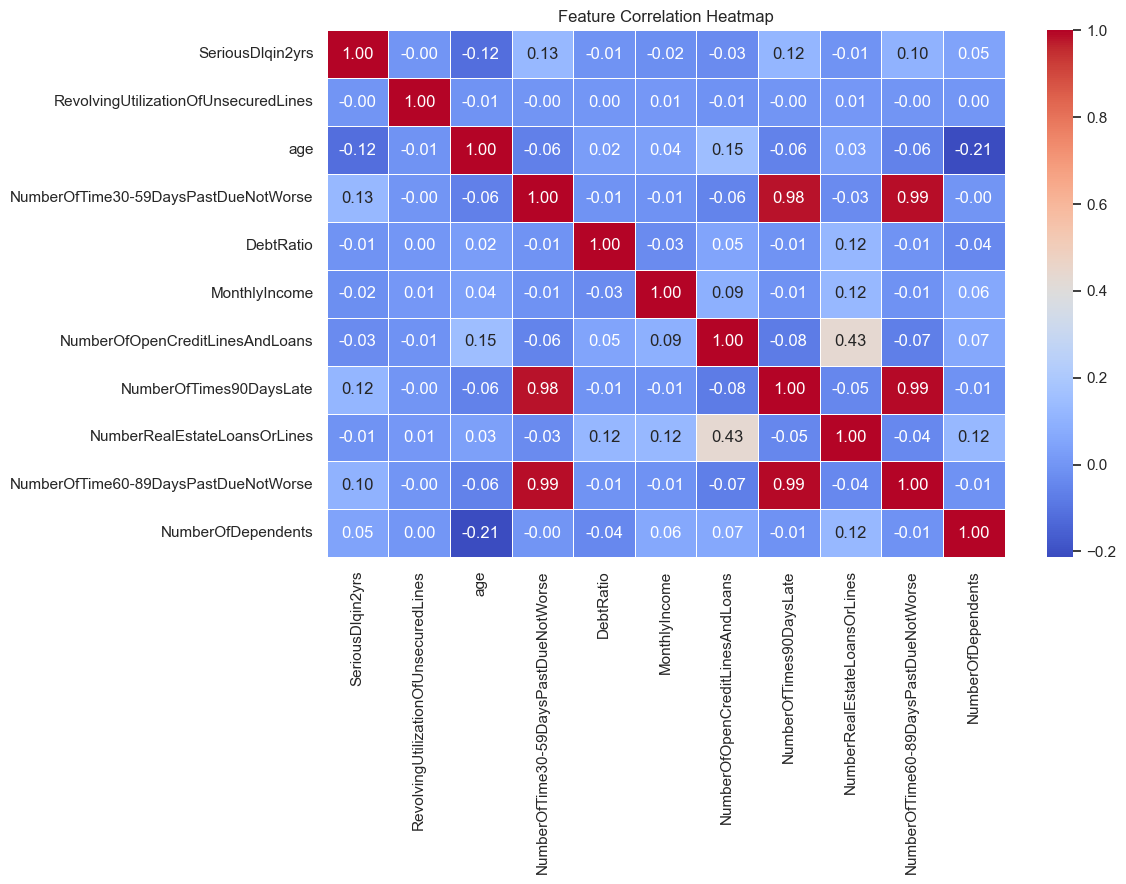

In [17]:
df_corr = df.copy()
corr = df_corr.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Baseline Model

In [18]:
df_bl = train.copy()
df_bl = df_bl.drop('Unnamed: 0', axis=1)
df_bl = df_bl.fillna(df_bl.median(numeric_only=True))
df_bl = df_bl.drop_duplicates()

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=14),
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1),
    'RandomForest': RandomForestClassifier()
}

In [21]:
x_bl = df_bl.drop('SeriousDlqin2yrs', axis=1)
y_bl = df_bl['SeriousDlqin2yrs']
x_train_bl, x_test_bl, y_train_bl, y_test_bl = train_test_split(
    x_bl, y_bl, test_size=0.2, random_state=14, stratify=y_bl)

In [22]:
result = {}
models_step1 = {}

In [23]:
from sklearn.metrics import recall_score, precision_score

In [24]:
# recall, precision
for name, model in models.items():
    model.fit(x_train_bl, y_train_bl)
    proba_test  = model.predict_proba(x_test_bl)[:, 1]
    prediction_train= model.predict_proba(x_train_bl)[:, 1]
    prediction_test   = model.predict(x_test_bl)

    auc = roc_auc_score(y_test_bl, prediction_test)
    f1 = f1_score(y_test_bl, prediction_test)
    precision = precision_score(y_test_bl, prediction_test)
    recall = recall_score(y_test_bl, prediction_test)
    overfit = roc_auc_score(y_train_bl, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step1[name] = model
    print(result[name] )

{'ROC-AUC': np.float64(0.5203), 'F1': 0.0799, 'Precision': 0.5695, 'Recall': 0.043, 'Overfit': np.float64(0.1754)}
{'ROC-AUC': np.float64(0.6036), 'F1': 0.313, 'Precision': 0.5371, 'Recall': 0.2209, 'Overfit': np.float64(0.3103)}
{'ROC-AUC': np.float64(0.5945), 'F1': 0.2969, 'Precision': 0.5808, 'Recall': 0.1994, 'Overfit': np.float64(0.3018)}
{'ROC-AUC': np.float64(0.5896), 'F1': 0.2812, 'Precision': 0.5297, 'Recall': 0.1914, 'Overfit': np.float64(0.4104)}


In [25]:
results_step1 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step1

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.6036,0.3130,0.5371,0.2209,0.3103
LightGBM,0.5945,0.2969,0.5808,0.1994,0.3018
RandomForest,0.5896,0.2812,0.5297,0.1914,0.4104
LogisticRegression,0.5203,0.0799,0.5695,0.0430,0.1754


In [26]:
from sklearn.model_selection import cross_validate

In [27]:
for name, model in models.items():
    scores = cross_validate(model, x_bl, y_bl, cv=5,
                            scoring=['roc_auc', 'f1', 'precision', 'recall'])

    result[name] = {
        'ROC-AUC': round(np.mean(scores['test_roc_auc']), 4),
        'F1':  round(np.mean(scores['test_f1']), 4),
        'Precision': round(np.mean(scores['test_precision']), 4),
        'Recall': round(np.mean(scores['test_recall']), 4),
    }
    print(name, result[name])

results_cv = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_cv

LogisticRegression {'ROC-AUC': np.float64(0.6969), 'F1': np.float64(0.0921), 'Precision': np.float64(0.6018), 'Recall': np.float64(0.0499)}
XGBoost {'ROC-AUC': np.float64(0.8556), 'F1': np.float64(0.2996), 'Precision': np.float64(0.5447), 'Recall': np.float64(0.2066)}
LightGBM {'ROC-AUC': np.float64(0.8644), 'F1': np.float64(0.287), 'Precision': np.float64(0.5878), 'Recall': np.float64(0.1899)}
RandomForest {'ROC-AUC': np.float64(0.8395), 'F1': np.float64(0.2803), 'Precision': np.float64(0.5452), 'Recall': np.float64(0.1887)}


,ROC-AUC,F1,Precision,Recall
LightGBM,0.8644,0.2870,0.5878,0.1899
XGBoost,0.8556,0.2996,0.5447,0.2066
RandomForest,0.8395,0.2803,0.5452,0.1887
LogisticRegression,0.6969,0.0921,0.6018,0.0499


На основе результатов сокращаю количество используемых моделей до 2 на основе f1_score: XGBoost, LightGBM. Также на основе результатов выбран: train_test_split

+feature engenireeng

In [28]:
from sklearn.impute import SimpleImputer

In [29]:
df_fe = train.copy()
df_fe = df_fe.drop('Unnamed: 0', axis=1)
df_fe = df_fe.fillna(df_fe.median(numeric_only=True))
df_fe = df_fe.drop_duplicates()

In [31]:
df_fe['debt_to_income'] = (
    df_fe['DebtRatio'] * df_fe['MonthlyIncome']
).clip(upper=df_fe['MonthlyIncome'].quantile(0.99) * 10)

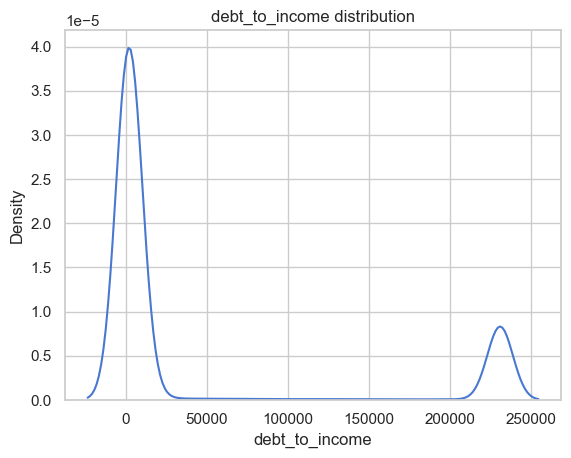

In [32]:
sns.kdeplot(df_fe['debt_to_income'])
plt.title('debt_to_income distribution')
plt.show()

In [33]:
df_fe['dependents_per_credit'] = (
    df_fe['NumberOfDependents'] /
    (df_fe['NumberOfOpenCreditLinesAndLoans'] + 1)
)

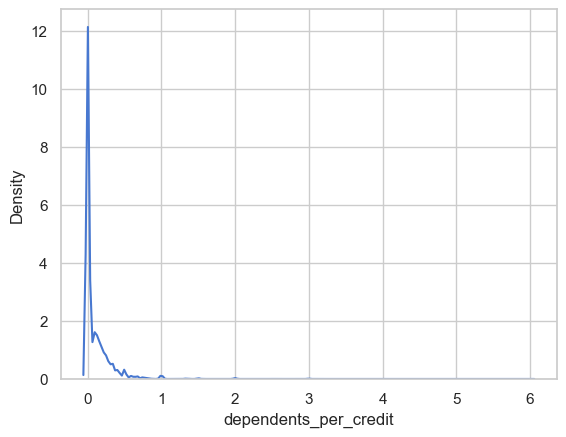

In [34]:
sns.kdeplot(df_fe['dependents_per_credit'])
plt.show()

In [35]:
df_fe.shape

(149233, 13)

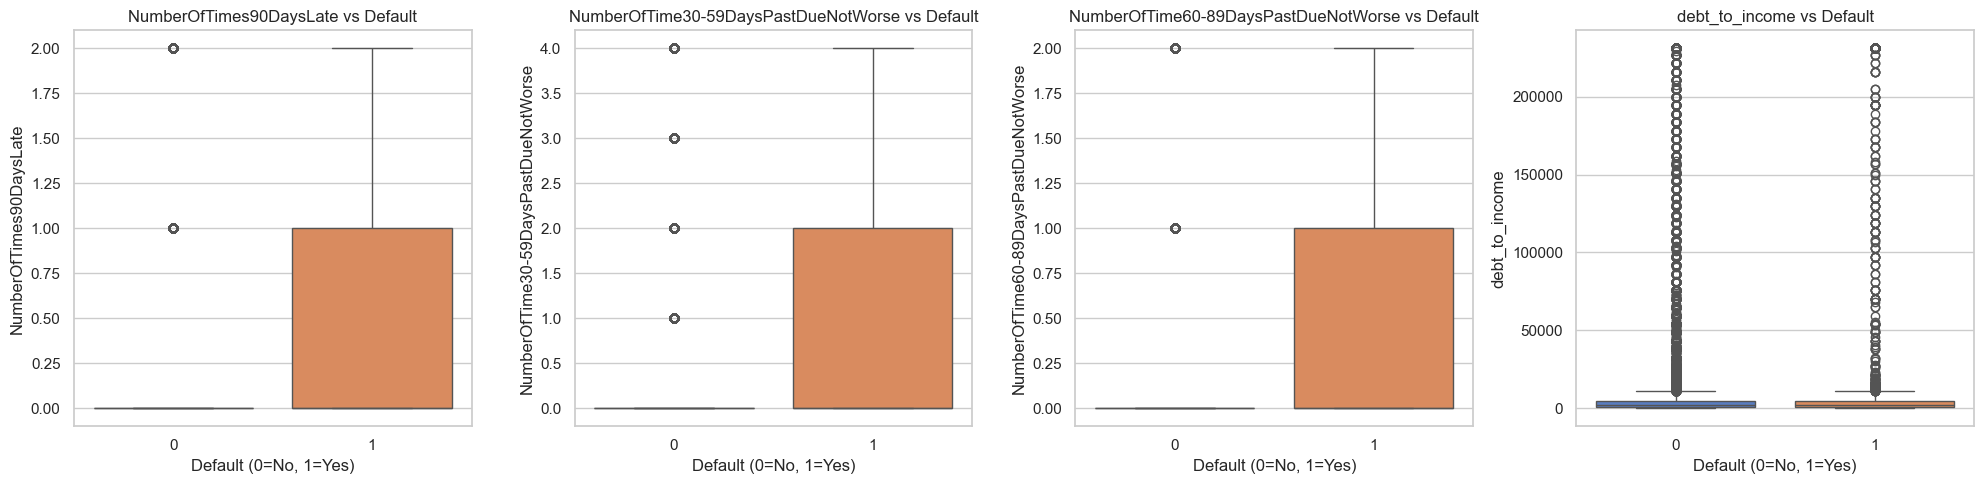

In [36]:
feats = ['NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
         'NumberOfTime60-89DaysPastDueNotWorse', 'debt_to_income']

fig, axes = plt.subplots(1, len(feats), figsize=(20, 5))

for ax, feat in zip(axes, feats):
    plot_df = df_fe.copy()
    plot_df[feat] = plot_df[feat].clip(upper=plot_df[feat].quantile(0.99))
    sns.boxplot(data=plot_df, x='SeriousDlqin2yrs', y=feat, ax=ax, palette='muted')
    ax.set_title(f'{feat} vs Default')
    ax.set_xlabel('Default (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

In [38]:
models_fe = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [39]:
x_fe = df_fe.drop('SeriousDlqin2yrs', axis=1)
y_fe = df_fe['SeriousDlqin2yrs']
x_train_fe, x_test_fe, y_train_fe, y_test_fe = train_test_split(
    x_fe, y_fe, test_size=0.2, random_state=14, stratify=y_fe)

In [40]:
result = {}
models_step2 = {}

In [41]:
for name, model in models_fe.items():
    model.fit(x_train_fe, y_train_fe)
    proba_test  = model.predict_proba(x_test_fe)[:, 1]
    prediction_train= model.predict_proba(x_train_fe)[:, 1]
    prediction_test   = model.predict(x_test_fe)

    auc = roc_auc_score(y_test_fe, prediction_test)
    f1 = f1_score(y_test_fe, prediction_test)
    precision = precision_score(y_test_fe, prediction_test)
    recall = recall_score(y_test_fe, prediction_test)
    overfit = roc_auc_score(y_train_fe, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step1[name] = model
    print(result[name])

{'ROC-AUC': np.float64(0.6053), 'F1': 0.3171, 'Precision': 0.5403, 'Recall': 0.2244, 'Overfit': np.float64(0.3134)}
{'ROC-AUC': np.float64(0.5926), 'F1': 0.2929, 'Precision': 0.5891, 'Recall': 0.1949, 'Overfit': np.float64(0.3039)}


In [42]:
results_step2 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step2

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.6053,0.3171,0.5403,0.2244,0.3134
LightGBM,0.5926,0.2929,0.5891,0.1949,0.3039


+advanced imputer

In [43]:
from sklearn.impute import SimpleImputer

In [44]:
df_ai = train.copy()
df_ai = df_ai.drop('Unnamed: 0', axis=1)
df_ai = df_ai.drop_duplicates()

In [45]:
models_ai = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [46]:
x_ai = df_ai.drop('SeriousDlqin2yrs', axis=1)
y_ai = df_ai['SeriousDlqin2yrs']
x_train_ai, x_test_ai, y_train_ai, y_test_ai = train_test_split(
    x_ai, y_ai, test_size=0.2, random_state=14, stratify=y_ai)

In [47]:
imputer = SimpleImputer(strategy='median')
x_train_ai = imputer.fit_transform(x_train_ai)
x_test_ai = imputer.transform(x_test_ai)

In [48]:
result = {}
models_step3 = {}

In [49]:
for name, model in models_ai.items():
    model.fit(x_train_ai, y_train_ai)
    proba_test  = model.predict_proba(x_test_ai)[:, 1]
    prediction_train= model.predict_proba(x_train_ai)[:, 1]
    prediction_test   = model.predict(x_test_ai)

    auc = roc_auc_score(y_test_ai, prediction_test)
    f1 = f1_score(y_test_ai, prediction_test)
    precision = precision_score(y_test_ai, prediction_test)
    recall = recall_score(y_test_ai, prediction_test)
    overfit = roc_auc_score(y_train_ai, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step3[name] = model
    print(result[name])

{'ROC-AUC': np.float64(0.5981), 'F1': 0.3045, 'Precision': 0.5732, 'Recall': 0.2073, 'Overfit': np.float64(0.3158)}
{'ROC-AUC': np.float64(0.5851), 'F1': 0.2759, 'Precision': 0.6092, 'Recall': 0.1783, 'Overfit': np.float64(0.3102)}


In [50]:
results_step3 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step3

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.5981,0.3045,0.5732,0.2073,0.3158
LightGBM,0.5851,0.2759,0.6092,0.1783,0.3102


стало хуже дальше не исспользуем

+Outlier Removal

In [51]:
df_cl = df_fe.copy()

In [52]:
cols_to_check = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
                 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
                 'NumberOfTime60-89DaysPastDueNotWorse', 'debt_to_income']

before = len(df_cl)
for col in cols_to_check:
    Q1  = df_cl[col].quantile(0.25)
    Q3  = df_cl[col].quantile(0.75)
    IQR = Q3 - Q1
    df_cl = df_cl[~((df_cl[col] < Q1 - 1.5*IQR) | (df_cl[col] > Q3 + 1.5*IQR))]

print(f'Removed: {before - len(df_cl)} rows')

Removed: 64880 rows


In [53]:
df_cl.shape

(84353, 13)

In [54]:
x_cl = df_cl.drop('SeriousDlqin2yrs', axis=1)
y_cl = df_cl['SeriousDlqin2yrs']
x_train_cl, x_test_cl, y_train_cl, y_test_cl = train_test_split(
    x_cl, y_cl, test_size=0.2, random_state=14, stratify=y_cl)

In [55]:
result = {}
models_step4 = {}

In [56]:
models_cl = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [57]:
for name, model in models_cl.items():
    model.fit(x_train_cl, y_train_cl)
    proba_test  = model.predict_proba(x_test_cl)[:, 1]
    prediction_train= model.predict_proba(x_train_cl)[:, 1]
    prediction_test   = model.predict(x_test_cl)

    auc = roc_auc_score(y_test_cl, prediction_test)
    f1 = f1_score(y_test_cl, prediction_test)
    precision = precision_score(y_test_cl, prediction_test)
    recall = recall_score(y_test_cl, prediction_test)
    overfit = roc_auc_score(y_train_cl, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step4[name] = model
    print(result[name])

{'ROC-AUC': np.float64(0.5049), 'F1': 0.0204, 'Precision': 0.2381, 'Recall': 0.0107, 'Overfit': np.float64(0.4495)}
{'ROC-AUC': np.float64(0.502), 'F1': 0.0084, 'Precision': 0.3333, 'Recall': 0.0043, 'Overfit': np.float64(0.4248)}


In [58]:
results_step4 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step4

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.5049,0.0204,0.2381,0.0107,0.4495
LightGBM,0.5020,0.0084,0.3333,0.0043,0.4248


Результат сильно упал, значит дальше не исспользуем

+Transformer
вместо Box-Cox-Transformer исспользую PowerTransformer, так как он может работать с 0

In [60]:
df_tr = df_fe.copy()

In [61]:
df_tr.shape

(149233, 13)

In [62]:
x_tr = df_cl.drop('SeriousDlqin2yrs', axis=1)
y_tr = df_cl['SeriousDlqin2yrs']
x_train_tr, x_test_tr, y_train_tr, y_test_tr = train_test_split(
    x_tr, y_tr, test_size=0.2, random_state=14, stratify=y_tr)

In [63]:
from sklearn.preprocessing import PowerTransformer

In [64]:
pt = PowerTransformer(method='yeo-johnson')
x_train_tr = pt.fit_transform(x_train_tr)
x_test_tr  = pt.transform(x_test_tr)

In [65]:
result = {}
models_step5 = {}

In [66]:
models_tr = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [67]:
for name, model in models_cl.items():
    model.fit(x_train_tr, y_train_tr)
    proba_test  = model.predict_proba(x_test_tr)[:, 1]
    prediction_train= model.predict_proba(x_train_tr)[:, 1]
    prediction_test   = model.predict(x_test_tr)

    auc = roc_auc_score(y_test_tr, prediction_test)
    f1 = f1_score(y_test_tr, prediction_test)
    precision = precision_score(y_test_tr, prediction_test)
    recall = recall_score(y_test_tr, prediction_test)
    overfit = roc_auc_score(y_train_tr, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step5[name] = model
    print(result[name])

{'ROC-AUC': np.float64(0.5051), 'F1': 0.0208, 'Precision': 0.3846, 'Recall': 0.0107, 'Overfit': np.float64(0.448)}
{'ROC-AUC': np.float64(0.4998), 'F1': 0.0, 'Precision': 0.0, 'Recall': 0.0, 'Overfit': np.float64(0.4204)}


In [68]:
results_step5 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step5

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.5051,0.0208,0.3846,0.0107,0.4480
LightGBM,0.4998,0.0000,0.0000,0.0000,0.4204


In [69]:
results_step2

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.6053,0.3171,0.5403,0.2244,0.3134
LightGBM,0.5926,0.2929,0.5891,0.1949,0.3039


Результат упал -> не исспользуем

+Lasso Feature Selection

In [70]:
! pip install kydavra

In [71]:
from kydavra import LassoSelector

In [72]:
df_lr = df_fe.copy()

In [73]:
all_features = list(df_fe.drop('SeriousDlqin2yrs', axis=1).columns)

In [74]:
lasso_sel = LassoSelector()
selected_columns = lasso_sel.select(df_fe, 'SeriousDlqin2yrs')
removed_features = [f for f in all_features if f not in selected_columns]

In [75]:
print(f'Selected ({len(selected_columns)}): {selected_columns}')
print(f'Removed  ({len(removed_features)}): {removed_features}')

Selected (0): []
Removed  (12): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'debt_to_income', 'dependents_per_credit']


как....

+Standardization

In [76]:
df_st = df_fe.copy()

In [77]:
x_st = df_fe.drop('SeriousDlqin2yrs', axis=1)
y_st = df_fe['SeriousDlqin2yrs']
x_train_st, x_test_st, y_train_st, y_test_st = train_test_split(
    x_st, y_st, test_size=0.2, random_state=14, stratify=y_st)

In [78]:
st = StandardScaler()
x_train_st = st.fit_transform(x_train_st)
x_test_st = st.transform(x_test_st)

In [79]:
models_st = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [80]:
result = {}
models_step6 = {}

In [83]:
for name, model in models_st.items():
    model.fit(x_train_st, y_train_st)
    proba_test  = model.predict_proba(x_test_st)[:, 1]
    prediction_train= model.predict_proba(x_train_st)[:, 1]
    prediction_test   = model.predict(x_test_st)

    auc = roc_auc_score(y_test_st, prediction_test)
    f1 = f1_score(y_test_st, prediction_test)
    precision = precision_score(y_test_st, prediction_test)
    recall = recall_score(y_test_st, prediction_test)
    overfit = roc_auc_score(y_train_st, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step6[name] = model
    print(result[name])

{'ROC-AUC': np.float64(0.6027), 'F1': 0.3113, 'Precision': 0.5387, 'Recall': 0.2189, 'Overfit': np.float64(0.3156)}
{'ROC-AUC': np.float64(0.5943), 'F1': 0.2972, 'Precision': 0.5917, 'Recall': 0.1984, 'Overfit': np.float64(0.3031)}


In [84]:
results_step6 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step6

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.6027,0.3113,0.5387,0.2189,0.3156
LightGBM,0.5943,0.2972,0.5917,0.1984,0.3031


+BorderlineSMOTE

In [85]:
bsmote = BorderlineSMOTE(random_state=14, kind='borderline-1')
x_train_im, y_train_im = bsmote.fit_resample(x_train_st, y_train_st)
x_test_im = x_test_st
y_test_im = y_test_st

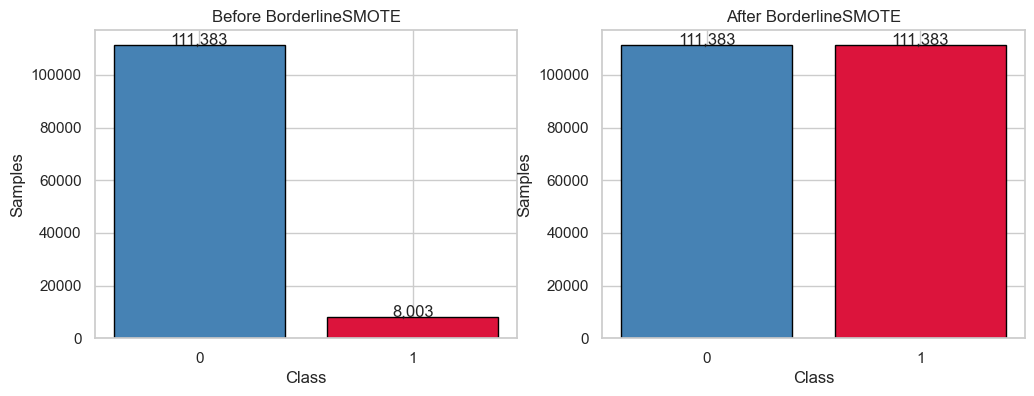

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before_counts = pd.Series(y_train_st).value_counts().sort_index()
axes[0].bar(before_counts.index.astype(str), before_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Before BorderlineSMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Samples')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center')
after_counts = pd.Series(y_train_im).value_counts().sort_index()
axes[1].bar(after_counts.index.astype(str), after_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[1].set_title('After BorderlineSMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Samples')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center')

In [87]:
models_im = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [88]:
result = {}
models_step7 = {}

In [89]:
for name, model in models_st.items():
    model.fit(x_train_im, y_train_im)
    proba_test  = model.predict_proba(x_test_im)[:, 1]
    prediction_train= model.predict_proba(x_train_im)[:, 1]
    prediction_test   = model.predict(x_test_im)

    auc = roc_auc_score(y_test_im, prediction_test)
    f1 = f1_score(y_test_im, prediction_test)
    precision = precision_score(y_test_im, prediction_test)
    recall = recall_score(y_test_im, prediction_test)
    overfit = roc_auc_score(y_train_im, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step7[name] = model
    print(result[name])

{'ROC-AUC': np.float64(0.6551), 'F1': 0.3654, 'Precision': 0.3806, 'Recall': 0.3513, 'Overfit': np.float64(0.3331)}
{'ROC-AUC': np.float64(0.6906), 'F1': 0.4099, 'Precision': 0.3927, 'Recall': 0.4288, 'Overfit': np.float64(0.2935)}


In [90]:
results_step7 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step7

,ROC-AUC,F1,Precision,Recall,Overfit
LightGBM,0.6906,0.4099,0.3927,0.4288,0.2935
XGBoost,0.6551,0.3654,0.3806,0.3513,0.3331



+Threshold Tuning

In [91]:
from sklearn.metrics import precision_recall_curve

In [92]:
models_tt = {
    'XGBoost':  XGBClassifier(random_state=14, verbosity=0, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=14, verbose=-1, n_jobs=-1)
}

In [93]:
result_thresh = {}
models_step8 = {}
best_thresholds = {}

In [94]:
for name, model in models_step7.items():
    proba          = model.predict_proba(x_test_im)[:, 1]
    proba_train    = model.predict_proba(x_train_im)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test_im, proba)
    f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx   = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_thresholds[name] = best_thresh

    y_pred = (proba >= best_thresh).astype(int)

    auc = roc_auc_score(y_test_im, prediction_test)
    f1 = f1_score(y_test_im, prediction_test)
    precision = precision_score(y_test_im, prediction_test)
    recall = recall_score(y_test_im, prediction_test)
    overfit = roc_auc_score(y_train_im, prediction_train) - auc

    result[name] = {'ROC-AUC': round(auc,4), 'F1': round(f1,4),
                    "Precision": round(precision,4),
                    "Recall": round(recall,4), 'Overfit': round(overfit,4)}
    models_step8[name] = model
    print(result[name])


{'ROC-AUC': np.float64(0.6906), 'F1': 0.4099, 'Precision': 0.3927, 'Recall': 0.4288, 'Overfit': np.float64(0.2935)}
{'ROC-AUC': np.float64(0.6906), 'F1': 0.4099, 'Precision': 0.3927, 'Recall': 0.4288, 'Overfit': np.float64(0.2935)}


In [95]:
results_step8 = pd.DataFrame(result).T.sort_values('ROC-AUC', ascending=False)
results_step8

,ROC-AUC,F1,Precision,Recall,Overfit
XGBoost,0.6906,0.4099,0.3927,0.4288,0.2935
LightGBM,0.6906,0.4099,0.3927,0.4288,0.2935


# Best model

In [96]:
best_name  = results_step8['F1'].idxmax()
best_model = models_step8[best_name]
best_thresh = best_thresholds[best_name]

In [97]:
print(f'Best model: {best_name} | F1={results_step8.loc[best_name, "F1"]} | Threshold={best_thresh:.3f}')

Best model: XGBoost | F1=0.4099 | Threshold=0.345


In [98]:
proba_test = best_model.predict_proba(x_test_im)[:, 1]
y_pred     = (proba_test >= best_thresh).astype(int)

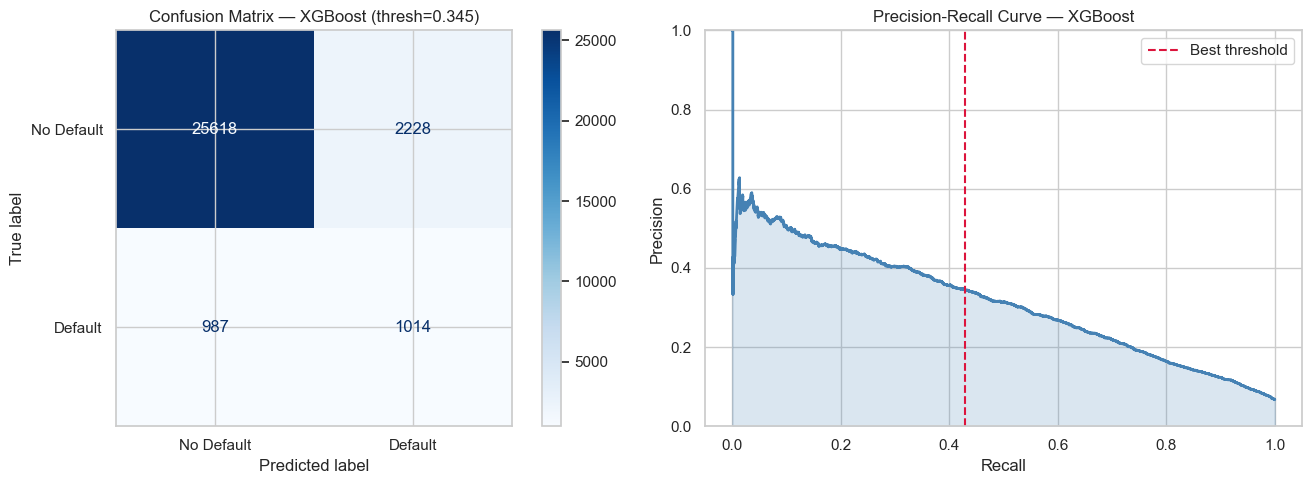

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_im, y_pred, ax=axes[0],
    display_labels=['No Default', 'Default'], cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix — {best_name} (thresh={best_thresh:.3f})')

prec, rec, _ = precision_recall_curve(y_test_im, proba_test)
axes[1].plot(rec, prec, color='steelblue', lw=2)
axes[1].fill_between(rec, prec, alpha=0.2, color='steelblue')
axes[1].axvline(x=results_step8.loc[best_name, 'Recall'],
                color='crimson', linestyle='--', label=f'Best threshold')
axes[1].set_title(f'Precision-Recall Curve — {best_name}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_ylim([0, 1])
axes[1].legend()

plt.tight_layout()
plt.show()

In [100]:
print(classification_report(y_test_im, y_pred, target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.96      0.92      0.94     27846
     Default       0.31      0.51      0.39      2001

    accuracy                           0.89     29847
   macro avg       0.64      0.71      0.66     29847
weighted avg       0.92      0.89      0.90     29847



Full final

In [125]:
df = train.copy()

In [126]:
df = train.copy()
df = df.drop('Unnamed: 0', axis=1)
df = df.fillna(df.median(numeric_only=True))
df = df.drop_duplicates()

In [141]:
df['debt_to_income'] = (
    df['DebtRatio'] * df['MonthlyIncome']
).clip(upper=df['MonthlyIncome'].quantile(0.99) * 10)

df['dependents_per_credit'] = (
    df['NumberOfDependents'] /
    (df['NumberOfOpenCreditLinesAndLoans'] + 1)
)

In [142]:
from sklearn.pipeline import Pipeline

In [143]:
x = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=14, stratify=y)

In [144]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

In [145]:
bsmote = BorderlineSMOTE(random_state=14, kind='borderline-1')
x_train, y_train = bsmote.fit_resample(x_train, y_train)

In [133]:
! pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]



In [149]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best ROC-AUC: {study.best_value:.4f}")
print(f"Best params:  {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best ROC-AUC: 0.8516
Best params:  {'n_estimators': 162, 'max_depth': 6, 'learning_rate': 0.012355604514925298, 'subsample': 0.9643046169839035, 'colsample_bytree': 0.6574555626955514, 'min_child_weight': 9, 'gamma': 4.595070116695515, 'reg_alpha': 2.7711021490657473, 'reg_lambda': 3.8760502408903648}


In [150]:
study.best_params

{'n_estimators': 162,
 'max_depth': 6,
 'learning_rate': 0.012355604514925298,
 'subsample': 0.9643046169839035,
 'colsample_bytree': 0.6574555626955514,
 'min_child_weight': 9,
 'gamma': 4.595070116695515,
 'reg_alpha': 2.7711021490657473,
 'reg_lambda': 3.8760502408903648}

In [151]:
final_model = XGBClassifier(
    **random_search.best_params_,
    random_state=14,
    verbosity=0,
    n_jobs=-1,
    eval_metric='logloss'
)
final_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [152]:
prediction_train = final_model.predict_proba(x_train)[:, 1]
prediction_test  = final_model.predict_proba(x_test)[:, 1]

In [153]:
precisions, recalls, thresholds = precision_recall_curve(y_train, proba_train)
f1_scores   = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1_scores)]

In [154]:
best_thresh

np.float64(0.5035613170288471)

In [155]:
y_pred = (proba_test >= best_thresh).astype(int)

auc       = roc_auc_score(y_test, proba_test)       # proba для ROC-AUC
f1        = f1_score(y_test, y_pred)                # y_pred для F1
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
overfit   = roc_auc_score(y_train, proba_train) - auc

results_final = pd.DataFrame([{
    'Model': 'XGBoost (tuned)',
    'ROC-AUC': round(auc, 4),
    'F1': round(f1, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'Overfit': round(overfit, 4),
    'Threshold': round(best_thresh, 4)
}]).set_index('Model')

In [156]:
results_final

,ROC-AUC,F1,Precision,Recall,Overfit,Threshold
Model,,,,,,
XGBoost (tuned),0.8354,0.3669,0.3844,0.3508,0.1488,0.5036


In [157]:
# После тюнинга результат немного ухудшился

Тест сет

In [158]:
df_test = test.copy()
df_test = df_test.drop('Unnamed: 0', axis=1)
df_test = df_test.fillna(df_test.median(numeric_only=True))

In [159]:
df_test['debt_to_income'] = (
    df_test['DebtRatio'] * df_test['MonthlyIncome']
).clip(upper=df['MonthlyIncome'].quantile(0.99) * 10)

In [160]:
df_test['dependents_per_credit'] = (
    df_test['NumberOfDependents'] /
    (df_test['NumberOfOpenCreditLinesAndLoans'] + 1)
)

In [161]:
df_test = df_test.drop('SeriousDlqin2yrs', axis=1)

In [162]:
x_final = scaler.transform(df_test)
y_final = final_model.predict(x_final)

In [163]:
submission = pd.DataFrame({
    'Id':         range(1, len(y_final) + 1),
    'Prediction': y_final
})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,Prediction
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


## Ethical Considerations

### Data Privacy
- The dataset contains personal financial data — income, debt, and payment history
- Data must be anonymized before use; individuals must not be re-identifiable

### Model Fairness
- The model must not discriminate based on protected attributes (age, gender, race)
- `age` is included as a risk indicator; its impact must be regularly audited
- Predictions should be equally calibrated across demographic groups

### Imbalance & Sampling Ethics
- BorderlineSMOTE creates synthetic samples — these must not be treated as real data
- Oversampling only in train set; test set reflects the true population distribution

### Data Usage
- Data used for educational purposes only
- Production deployment must comply with:
  - GDPR (EU borrowers)
  - Fair Credit Reporting Act (FCRA) — US
  - Equal Credit Opportunity Act (ECOA) — US

### Security
- Credit risk scores must not be exposed to unauthorized third parties
- Model decisions affecting credit must be explainable and auditable